# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title


In [5]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())


Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [6]:
print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

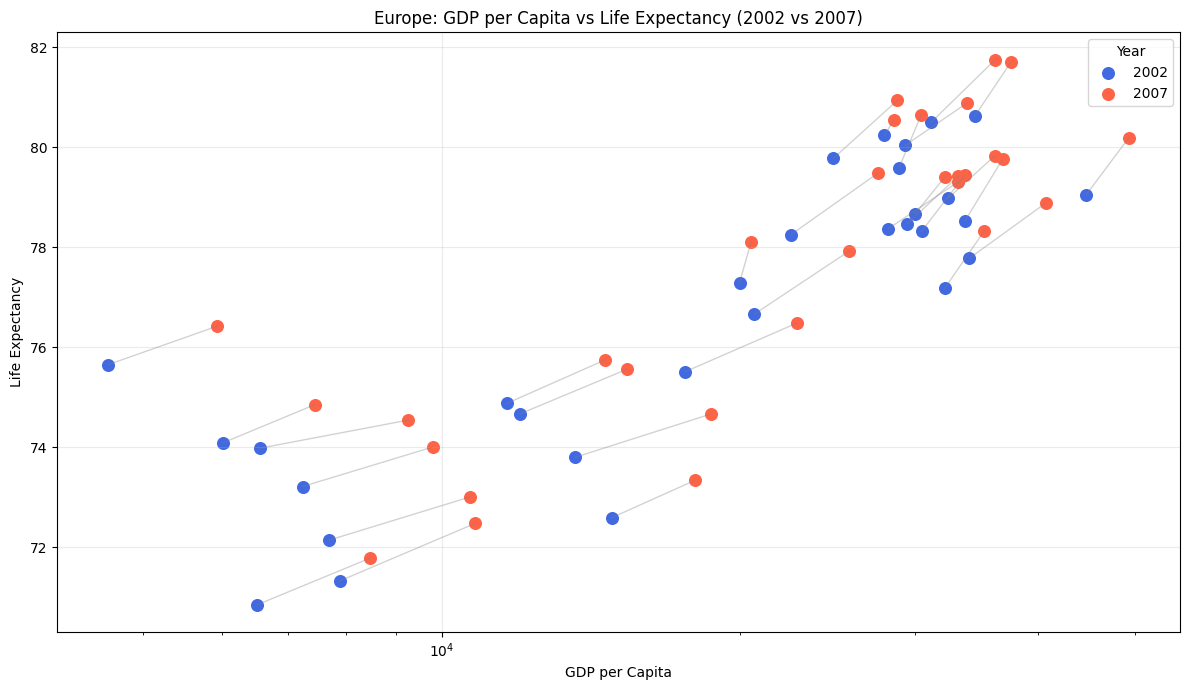

In [8]:
#Task01

import pandas as pd
import matplotlib.pyplot as plt

# Choose one continent (not Africa)
continent = 'Europe'

# Filter selected continent and years
filtered = df[
    (df['continent'] == continent) &
    (df['year'].isin([2002, 2007]))
]

# Separate the two years
df_2002 = filtered[filtered['year'] == 2002]
df_2007 = filtered[filtered['year'] == 2007]

# Merge by country so movement can be shown
merged = pd.merge(
    df_2002[['country', 'gdpPercap', 'lifeExp']],
    df_2007[['country', 'gdpPercap', 'lifeExp']],
    on='country',
    suffixes=('_2002', '_2007')
)

plt.figure(figsize=(12, 7))

# Draw movement lines
for _, row in merged.iterrows():
    plt.plot(
        [row['gdpPercap_2002'], row['gdpPercap_2007']],
        [row['lifeExp_2002'], row['lifeExp_2007']],
        color='gray',
        alpha=0.35,
        linewidth=1
    )

# Scatter for 2002
plt.scatter(
    df_2002['gdpPercap'],
    df_2002['lifeExp'],
    color='royalblue',
    s=70,
    label='2002'
)

# Scatter for 2007
plt.scatter(
    df_2007['gdpPercap'],
    df_2007['lifeExp'],
    color='tomato',
    s=70,
    label='2007'
)

plt.xscale('log')
plt.xlabel('GDP per Capita')
plt.ylabel('Life Expectancy')
plt.title(f'{continent}: GDP per Capita vs Life Expectancy (2002 vs 2007)')

plt.legend(title='Year')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

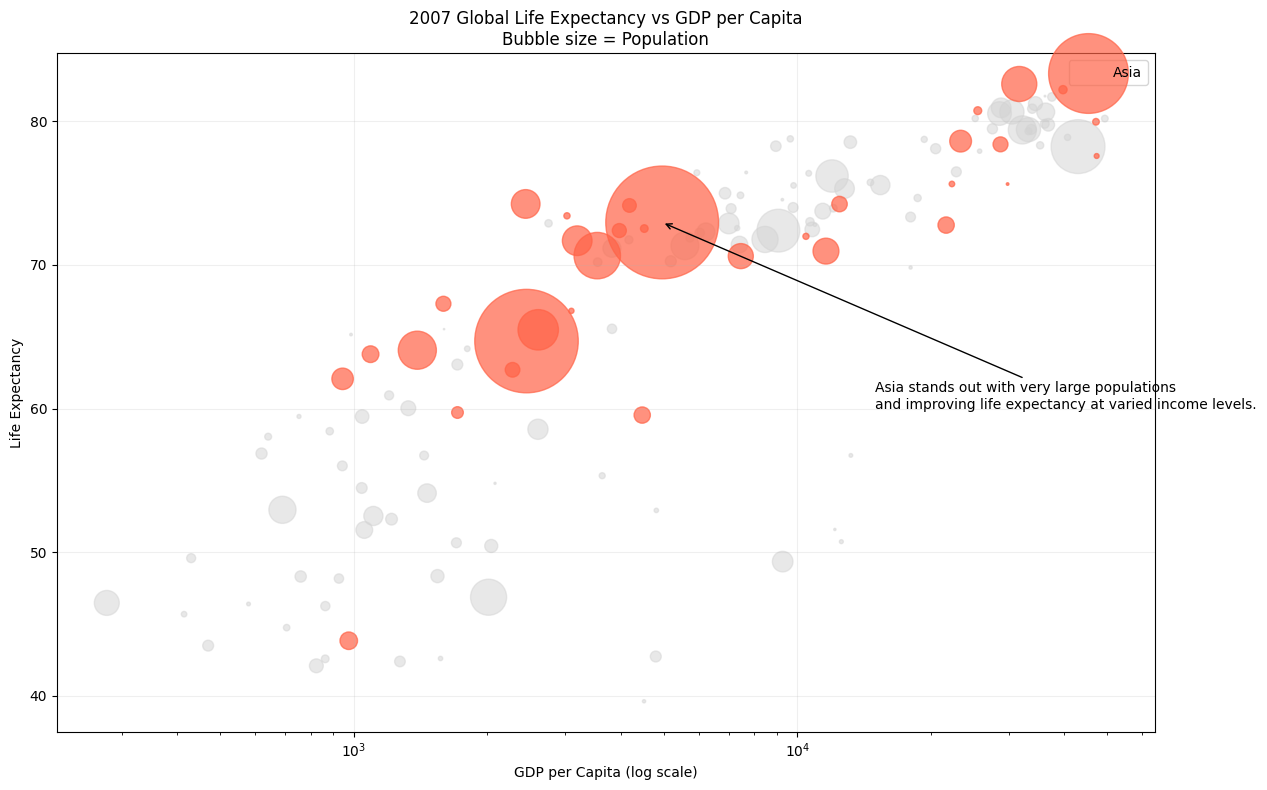

In [9]:
# Task 2

import pandas as pd
import matplotlib.pyplot as plt

# Filter only 2007 data
df_2007 = df[df['year'] == 2007].copy()

# Choose one continent to highlight
highlight_continent = 'Asia'

# Split highlighted continent and others
highlight = df_2007[df_2007['continent'] == highlight_continent]
others = df_2007[df_2007['continent'] != highlight_continent]

# Scale population for bubble size
size_scale = 200000

plt.figure(figsize=(13, 8))

# Plot all other continents in grey
plt.scatter(
    others['gdpPercap'],
    others['lifeExp'],
    s=others['pop'] / size_scale,
    color='lightgray',
    alpha=0.5
)

# Plot highlighted continent
plt.scatter(
    highlight['gdpPercap'],
    highlight['lifeExp'],
    s=highlight['pop'] / size_scale,
    color='tomato',
    alpha=0.7,
    label=highlight_continent
)

# Use log scale for GDP
plt.xscale('log')

# Add annotation (story)
china = highlight[highlight['country'] == 'China'].iloc[0]

plt.annotate(
    'Asia stands out with very large populations\nand improving life expectancy at varied income levels.',
    xy=(china['gdpPercap'], china['lifeExp']),
    xytext=(15000, 60),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)

plt.xlabel('GDP per Capita (log scale)')
plt.ylabel('Life Expectancy')
plt.title('2007 Global Life Expectancy vs GDP per Capita\nBubble size = Population')

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()